# Valuing Datadog with `techval`

A walk through one real company end to end: normalized filings, the enterprise
value bridge, cost of capital, a discounted cash flow, trading comparables, and
the football field that puts them side by side.

The notebook runs against the **frozen test fixtures** committed with the
package, so it executes offline and returns the same numbers every time. Point
`build_financials` at a live `EdgarClient` and swap the price source to `nasdaq`
to run it against today's filings instead.

Read `docs/methodology.md` alongside this. The judgment calls are argued there;
here we mostly watch them take effect.

In [1]:
import json
from datetime import date
from pathlib import Path

import pandas as pd

from techval.config import Assumptions
from techval.edgar import CompanyFacts, HttpCache
from techval.financials import build_financials
from techval.ev_bridge import build_ev_bridge, equity_value_from_ev
from techval.market import MarketData, CsvSource
from techval.wacc import compute_wacc, estimate_beta
from techval.dcf import run_dcf, sensitivity_wacc_growth
from techval.comps import run_comps
from techval.football import FootballRow, football_field

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
FIXTURES = ROOT / "tests" / "fixtures"

# Fixtures were retrieved on this date; pinning it fixes the 52-week window
# and the beta lookback so the notebook is reproducible.
AS_OF = date(2026, 9, 10)

def facts(ticker):
    return CompanyFacts(json.loads((FIXTURES / f"companyfacts_{ticker}.json").read_text()), ticker)

class FixtureClient:
    def company_facts(self, ticker):
        return facts(ticker.upper())

market = MarketData(CsvSource(FIXTURES / "prices"), HttpCache(enabled=False), today=AS_OF)
assumptions = Assumptions.load(ROOT / "assumptions.example.yaml")
assumptions.market.risk_free_rate = 0.0483   # pin the Treasury print, offline
assumptions.comps.peers = ["CRWD", "MDB", "ZS"]   # the peers we hold fixtures for

## 1. Normalized statements

Nothing here is typed in by hand. Each line is resolved from XBRL through an
ordered ladder of us-gaap tags, aggregated over the trailing twelve months by
tiling reported periods, and carries a provenance record.

In [2]:
fin = build_financials("DDOG", facts=facts("DDOG"))
price = market.spot("DDOG")

print(f"{fin.entity_name}  CIK {fin.cik}")
print(f"twelve months ended {fin.as_of}\n")

pd.DataFrame(
    [
        ("Revenue", fin.revenue),
        ("Gross profit", fin.gross_profit),
        ("EBIT", fin.ebit),
        ("D&A", fin.da),
        ("EBITDA", fin.ebitda),
        ("Stock-based compensation", fin.sbc),
        ("Net income", fin.net_income),
        ("Capital expenditure", fin.capex),
        ("Diluted shares (mm)", fin.diluted_shares),
    ],
    columns=["Line", "USD mm"],
).assign(**{"% of revenue": lambda d: (d["USD mm"] / fin.revenue).map("{:.1%}".format)})

Datadog, Inc.  CIK 1561550
twelve months ended 2026-06-30



,Line,USD mm,% of revenue
0,Revenue,3966.725000,100.0%
1,Gross profit,3154.033000,79.5%
2,EBIT,16.329000,0.4%
3,D&A,62.000000,1.6%
4,EBITDA,78.329000,2.0%
5,Stock-based compensation,823.037000,20.7%
6,Net income,177.584000,4.5%
7,Capital expenditure,46.925000,1.2%
8,Diluted shares (mm),366.934307,9.3%


The first thing worth noticing is the shape of this business on a GAAP basis:
stock compensation runs at roughly 21% of revenue while EBIT margin is under one
percent. Almost the whole of the operating margin is being paid out in equity.
Every valuation decision below is dominated by how that one line is treated.

In [3]:
# Where each figure came from. This is the audit trail.
prov = pd.DataFrame(fin.provenance_rows())
prov[prov["concept"].isin(
    ["revenue", "EBIT", "D&A", "diluted shares", "short-term investments",
     "convertible notes, non-current", "non-controlling interest"]
)][["concept", "tag", "method", "period", "form"]]

,concept,tag,method,period,form
0,revenue,RevenueFromContractWithCustomerExcludingAssess...,"2 periods tiled to twelve months, some recover...","2025-07-01..2025-12-31, 2026-01-01..2026-06-30","10-K, 10-Q"
1,EBIT,OperatingIncomeLoss,"2 periods tiled to twelve months, some recover...","2025-07-01..2025-12-31, 2026-01-01..2026-06-30","10-K, 10-Q"
3,D&A,DepreciationDepletionAndAmortization,"2 periods tiled to twelve months, some recover...","2025-07-01..2025-12-31, 2026-01-01..2026-06-30","10-K, 10-Q"
12,diluted shares,WeightedAverageNumberOfDilutedSharesOutstanding,"2 periods tiled to twelve months, some recover...","2025-07-01..2025-12-31, 2026-01-01..2026-06-30","10-K, 10-Q"
15,short-term investments,AvailableForSaleSecuritiesDebtSecuritiesCurrent,"balance sheet, latest instant",2026-06-30,10-Q
19,"convertible notes, non-current",ConvertibleLongTermNotesPayable,"balance sheet, latest instant",2026-06-30,10-Q
25,non-controlling interest,-,"absent, defaulted",-,-


Two rows there repay attention.

`diluted shares` is aggregated as a **day-weighted average**, not a sum. A
weighted-average share count is an average over its window, so four quarterly
values cannot be added and a half-year cannot be subtracted from a nine-month
figure. The engine converts these to integrals (average times days) before any
period arithmetic, then divides back out.

`non-controlling interest` reads `absent, defaulted`. Datadog has none, and zero
is the right answer, but the provenance says the figure was defaulted rather than
sourced, so nobody mistakes an assumption for a filing.

In [4]:
for w in fin.warnings:
    print("!", w)
if not fin.warnings:
    print("(no data-quality warnings for DDOG)")

# CrowdStrike is the interesting case: it split four-for-one in mid-2026.
crwd = build_financials("CRWD", facts=facts("CRWD"))
print()
for w in crwd.warnings:
    print("CRWD !", w)

(no data-quality warnings for DDOG)

CRWD ! operating lease cost: only reported annually, so the figure shown is 2025-02-01..2026-01-31, not the trailing twelve months
CRWD ! 4-for-1 share split first reflected in the filing of 2026-08-27. Share counts and per-share figures from earlier filings have been restated into current units before any period was aggregated


That split matters more than it looks. Periods filed before it keep their
pre-split share counts in `companyfacts` forever, because no later filing
restates them. A trailing twelve months that mixes restated and unrestated
quarters returns roughly 271mm shares against a true post-split 1,023mm, an
error of about 4x flowing straight into equity value and every per-share figure
built on it. The engine detects the split from the filings themselves and
restates the earlier facts into current units.

## 2. Enterprise value bridge

Two decisions carry this section: what to do with operating leases, and what to
do with convertible notes.

In [5]:
bridge = build_ev_bridge(fin, price, assumptions)
pd.DataFrame(bridge.rows(), columns=["", "USD mm"])

,,USD mm
0,Share price,225.270000
1,Diluted shares (mm),366.934307
2,Equity value,82659.291304
3,+ Straight debt,0.000000
4,+ Convertible notes,0.000000
5,+ Finance leases,0.000000
6,+ Operating leases,0.000000
7,+ Preferred stock,0.000000
8,+ Non-controlling interest,0.000000
9,- Cash and equivalents,-434.957000


In [6]:
print("Convention:", bridge.lease_convention)
print("Convertible treatment:", bridge.convertible_treatment)
print()
for n in bridge.notes:
    print("-", n)

den, label = bridge.multiple_denominator(fin)
print(f"\nMultiples pair this EV with {label} = {den:,.1f}mm")

Convention: operating leases excluded, EBITDA basis (ASC 842)
Convertible treatment: if_converted

- Convertible notes of 986mm are in the money at 225.27 against a 148.15 conversion price. Under ASU 2020-06 their shares are already in diluted WASO, so they are carried as equity, not debt.
- Checked: conversion would create 6.7mm shares and diluted WASO runs 14.6mm above basic, so the shares are inside the count the equity value is built on.

Multiples pair this EV with EBITDA (after operating lease cost, per ASC 842) = 78.3mm


**Convertibles.** ASU 2020-06 made the if-converted method mandatory, so a
dilutive convertible's full conversion shares already sit inside diluted
weighted-average shares. Datadog's notes convert around \$148 with the stock
above \$200, so they are deep in the money and their shares are already in the
366.9mm denominator. Adding the \$986mm principal to debt as well would count the
same instrument twice.

Here is the size of that error:

In [7]:
from copy import deepcopy

a_debt = deepcopy(assumptions); a_debt.convertibles.treatment = "debt"
a_conv = deepcopy(assumptions); a_conv.convertibles.treatment = "if_converted"

ev_debt = build_ev_bridge(fin, price, a_debt).enterprise_value
ev_conv = build_ev_bridge(fin, price, a_conv).enterprise_value

print(f"convertibles as debt          EV {ev_debt:12,.0f}")
print(f"convertibles as equity        EV {ev_conv:12,.0f}")
print(f"difference                       {ev_debt - ev_conv:12,.0f}  (= the note principal)")

convertibles as debt          EV       78,659
convertibles as equity        EV       77,674
difference                                986  (= the note principal)


**Operating leases.** Under ASC 842 the lease charge stays inside operating
income as straight-line rent, and is not split into depreciation and interest the
way IFRS 16 requires. So US-GAAP EBITDA is already *after* rent. Counting the
lease liability as debt while dividing by that same EBITDA charges the lease
twice: once as a claim in the numerator, once as a charge that suppressed the
denominator.

The engine reports both enterprise values under either setting, and the earnings
figure that legitimately pairs with the chosen one is only reachable through
`multiple_denominator`, so the two conventions cannot be mixed by accident.

In [8]:
a_leased = deepcopy(assumptions); a_leased.leases.capitalize_operating_leases = True
leased = build_ev_bridge(fin, price, a_leased)

pd.DataFrame([
    {"convention": "leases excluded (default)",
     "EV": bridge.enterprise_value,
     "denominator": bridge.multiple_denominator(fin)[1],
     "value": bridge.multiple_denominator(fin)[0],
     "EV / denominator": bridge.enterprise_value / bridge.multiple_denominator(fin)[0]},
    {"convention": "leases in debt",
     "EV": leased.enterprise_value,
     "denominator": leased.multiple_denominator(fin)[1],
     "value": leased.multiple_denominator(fin)[0],
     "EV / denominator": leased.enterprise_value / leased.multiple_denominator(fin)[0]},
])

,convention,EV,denominator,value,EV / denominator
0,leases excluded (default),77673.853304,"EBITDA (after operating lease cost, per ASC 842)",78.329,991.635962
1,leases in debt,77966.109304,EBITDAR (before operating lease cost),135.092,577.133430


## 3. Cost of capital

Beta is the median of the peers' **asset** betas, relevered at Datadog's own
capital structure. Unlevering each peer at its own D/E before averaging is what
strips out financing policy so that what gets pooled is business risk.

In [9]:
peer_betas = []
for t in assumptions.comps.peers:
    peer_fin = build_financials(t, facts=facts(t))
    peer_bridge = build_ev_bridge(peer_fin, market.spot(t), assumptions)
    de = max(peer_bridge.total_debt / peer_bridge.equity_value, 0.0)
    peer_betas.append(
        estimate_beta(
            market.prices(t), market.prices("SPY"),
            debt_to_equity=de, tax_rate=assumptions.tax.marginal_tax_rate,
            lookback_years=assumptions.market.beta_lookback_years,
        )
    )

pd.DataFrame([b.rows() if hasattr(b, "rows") else {
    "ticker": b.ticker, "raw beta": b.raw_beta, "unlevered": b.unlevered_beta,
    "R2": b.r_squared, "s.e.": b.stderr, "n": b.n_observations,
} for b in peer_betas])

,ticker,raw beta,unlevered,R2,s.e.,n
0,CRWD,1.628434,1.624100,0.242984,0.284599,104
1,MDB,1.987001,1.985636,0.200053,0.393420,104
2,ZS,1.155429,1.155429,0.131301,0.294269,104


The R-squared column is the one to look at. These regressions explain a small
share of each stock's weekly variance, which is normal for a single high-growth
name and is exactly why the peer median is used rather than any one company's
own beta. A point estimate printed without its standard error invites more
confidence than the data supports.

In [10]:
wacc = compute_wacc(fin, bridge, market, assumptions, peer_betas=peer_betas)
pd.DataFrame(wacc.buildup_rows())[["label", "value", "source"]]

,label,value,source
0,Risk-free rate,0.048300,assumptions file override
1,Equity risk premium,0.050000,assumption: market.equity_risk_premium
2,Levered beta,1.624100,"median of 3 peer unlevered betas (CRWD, MDB, Z..."
3,Unlevered beta,1.624100,Hamada on each peer at its own D/E and tax rat...
4,Size premium,0.000000,assumption: market.size_premium
5,Pre-tax cost of debt,0.112700,synthetic: EBIT/interest of 1.4x maps to B3/B-...
6,Tax rate,0.240000,assumption: tax.marginal_tax_rate
7,After-tax cost of debt,0.085652,11.27% x (1 - 24.0%)
8,Market value of equity,82659.291304,225.27 x 366.9mm diluted shares
9,Total debt (book),0.000000,"EV bridge at book value, operating leases excl..."


In [11]:
for n in wacc.notes:
    print("-", n)

- Peer regressions: R-squared runs 0.13 to 0.24 and the slope standard error 0.28 to 0.39 across 3 names, each on at least 104 weekly observations. The median asset beta pools these estimates; it does not sharpen any one of them.
- DDOG is net cash by 4,985mm. Weights still use gross debt of 0mm, because the tax shield attaches to debt outstanding and not to a net position. At a 0.0% debt weight the WACC is its cost of equity to within a few basis points.
- Gross debt reads 0mm despite 986mm of convertible notes outstanding, because the bridge carries those as equity under the if-converted treatment: their shares already sit in the diluted count the equity weight is built on. Counting them as debt here while counting their shares in equity would weight the same instrument twice.


Note the cost of debt. Interest coverage is the wrong risk metric for a company
holding \$5bn of cash against \$986mm of zero-coupon convertibles, and the
synthetic rating it produces is far too harsh. It barely reaches the answer here
because the debt weight is essentially zero, and the output says so, but for a
company with real debt *and* real cash you would override the rate.

## 4. Discounted cash flow

In [12]:
dcf = run_dcf(fin, bridge, wacc, assumptions, peer_median_ev_ebitda=None)
frame = dcf.to_frame()
frame.style.format("{:,.1f}") if hasattr(frame, "style") else frame

,Revenue,Growth,EBIT,EBIT margin,Taxes,NOPAT,D&A,Capex,Change in NWC,SBC,FCFF,Discount factor,PV
Year,,,,,,,,,,,,,
1,"4,839.4",0.2,19.9,0.0,4.8,15.1,96.8,145.2,-52.4,"1,004.1",19.1,0.9,18.0
2,"5,734.7",0.2,333.1,0.1,79.9,253.2,114.7,172.0,-53.7,"1,189.9",249.5,0.8,207.9
3,"6,594.9",0.1,739.0,0.1,177.4,561.6,131.9,197.8,-51.6,"1,368.3",547.3,0.7,403.7
4,"7,353.3",0.1,"1,220.9",0.2,293.0,927.9,147.1,220.6,-45.5,"1,525.7",899.8,0.7,587.6
5,"7,941.6",0.1,"1,747.1",0.2,419.3,"1,327.8",158.8,238.2,-35.3,"1,647.8","1,283.7",0.6,742.1


In [13]:
print(f"WACC                             {dcf.wacc:.2%}")
print(f"Enterprise value, Gordon growth  {dcf.enterprise_value_gordon:12,.0f}")
print(f"Equity value, Gordon growth      {dcf.equity_value_gordon:12,.0f}")
print(f"Implied per share                {dcf.per_share_gordon:12,.2f}")
print(f"Market price                     {price:12,.2f}")
print()
for c in dcf.checks:
    print("-", c)

WACC                             12.95%
Enterprise value, Gordon growth         9,238
Equity value, Gordon growth            14,223
Implied per share                       38.76
Market price                           225.27

- Terminal growth of 2.50% sits below the 4.83% risk-free rate, so the perpetuity does not outgrow the long bond.
- The Gordon terminal value implies an exit multiple of 7.0x terminal EBITDA of 1,906mm, restated onto the exit method's whole-period discount clock so the comparison is like for like.
- FLAG: Gordon terminal value is 79% of enterprise value, above the 75% mark. The valuation is a bet on the terminal assumption, not on the forecast. Extending the explicit period until the business is mature moves the judgment into years that can be argued about.
- Steady-state reinvestment at 2.50% growth is 69mm on 1,361mm of NOPAT, a reinvestment rate of 5.1%. It implies a terminal ROIC of 49.0% against a WACC of 12.95%, so terminal growth creates value and the assump

The cross-checks are the point of this section, more than the headline number.

The Gordon terminal value implies an exit multiple far below what the peer set
trades at, four fifths of the enterprise value sits in the terminal assumption,
and the terminal reinvestment rate implies a return on capital that assumes no
competitor ever arrives. In perpetuity `g = ROIC x reinvestment rate`, so a
terminal year that grows at 2.5% while reinvesting 3% of NOPAT is implicitly
claiming a 75% return on incremental capital, forever.

A DCF that survives those four checks is internally consistent. One that does not
is arithmetic with a story attached, and it is better to see that on screen than
to discover it in a meeting.

### The stock compensation switch

This is the largest single judgment in a software DCF.

In [14]:
a_expense = deepcopy(assumptions); a_expense.dcf.sbc_treatment = "expense"
a_addback = deepcopy(assumptions); a_addback.dcf.sbc_treatment = "addback"

rows = []
for label, a in (("SBC expensed (default)", a_expense), ("SBC added back", a_addback)):
    d = run_dcf(fin, bridge, wacc, a)
    rows.append({
        "treatment": label,
        "EV": d.enterprise_value_gordon,
        "equity value": d.equity_value_gordon,
        "per share": d.per_share_gordon,
    })
pd.DataFrame(rows)

,treatment,EV,equity value,per share
0,SBC expensed (default),9237.948434,14223.386434,38.762760
1,SBC added back,23474.898252,28460.336252,77.562484


GAAP EBIT is already net of stock compensation, so `expense` adds nothing back:
free cash flow is struck after the full cost of paying employees. `addback`
restores it as a non-cash charge, which is defensible only alongside a growing
share count. Adding back the benefit while holding the denominator flat counts
one side of the transaction and ignores the other.

### Sensitivity

In [15]:
sensitivity_wacc_growth(fin, bridge, assumptions, wacc.wacc)

Terminal growth,1.5%,2.0%,2.5%,3.0%,3.5%
WACC,,,,,
11.5%,41.086813,42.359620,43.774631,45.357090,47.138587
12.2%,38.817809,39.888938,41.070488,42.380459,43.840993
13.0%,36.853746,37.764670,38.762760,39.861155,41.075776
13.7%,35.138156,35.919962,36.771569,37.702761,38.725242
14.5%,33.627662,34.304078,35.037096,35.834129,36.703948


## 5. Trading comparables

In [16]:
comps = run_comps("DDOG", assumptions, FixtureClient(), market)
comps.table()

,Ticker,Company,Price,Market cap,EV,Revenue,Rev growth,Gross margin,EBITDA margin,Rule of 40,EV/Revenue,EV/Gross Profit,EV/EBITDA,EV/EBIT,P/E,Flags
0,CRWD,"CROWDSTRIKE HOLDINGS, INC.",207.80,212534.881270,208305.051270,5396.145,0.243036,0.751900,NaN,NaN,38.602567,51.340009,None,None,None,EV/EBITDA NM: EBITDA (after operating lease co...
1,MDB,"MONGODB, INC.",358.38,29214.187023,26829.351023,2782.770,0.254523,0.726877,0.003011,25.753443,9.641239,13.263918,None,None,None,"EV/EBITDA NM: 3,202x exceeds the 100x cut-off ..."
2,ZS,Zscaler Inc,166.10,26612.375900,24834.579900,3352.523,0.254163,0.768047,0.004557,25.872027,7.407728,9.644894,None,None,None,"Convertible notes of 1,696mm are carried as de..."


In [17]:
print("Peer statistics")
display(comps.stats)
print("\nImplied value for DDOG")
display(comps.implied)

if comps.exclusions:
    print("\nExcluded peers")
    for e in comps.exclusions:
        print(f"  {e.ticker}: {e.reason}")

print("\nSuppressed multiples")
for p in comps.peers:
    for f in p.flags:
        print(f"  {p.ticker}: {f}")

Peer statistics


,EV/Revenue,EV/Gross Profit,EV/EBITDA,EV/EBIT,P/E
n,3.000000,3.000000,0.0,0.0,0.0
Min,7.407728,9.644894,NaN,NaN,NaN
p25,8.524484,11.454406,NaN,NaN,NaN
Median,9.641239,13.263918,NaN,NaN,NaN
p75,24.121903,32.301963,NaN,NaN,NaN
Max,38.602567,51.340009,NaN,NaN,NaN



Implied value for DDOG


,n,Target metric,Peer p25,Peer p75,Implied EV low,Implied EV high,Implied price low,Implied price high
Methodology,,,,,,,,
EV/Revenue,3,3966.725,8.524484,24.121903,33814.282906,95684.956812,105.740238,274.355363
EV/Gross Profit,3,3154.033,11.454406,32.301963,36127.574366,101881.457915,112.044613,291.242585



Suppressed multiples
  CRWD: EV/EBITDA NM: EBITDA (after operating lease cost, per ASC 842) cannot be formed from this filer's tags
  CRWD: EV/EBIT NM: EBIT margin -2.5%
  CRWD: P/E NM: 4,724x exceeds the 75x cut-off on a net margin of 0.8%
  MDB: EV/EBITDA NM: 3,202x exceeds the 100x cut-off on an EBITDA margin of 0.3%
  MDB: EV/EBIT NM: EBIT margin -0.5%
  MDB: P/E NM: 496x exceeds the 75x cut-off on a net margin of 2.1%
  ZS: Convertible notes of 1,696mm are carried as debt because no conversion price was supplied. If they are in the money their shares are already inside diluted WASO and enterprise value is overstated by up to that amount. Set convertibles.conversion_price from the notes footnote to resolve this.
  ZS: EV/EBITDA NM: 1,626x exceeds the 100x cut-off on an EBITDA margin of 0.5%
  ZS: EV/EBIT NM: EBIT margin -4.0%
  ZS: P/E NM: GAAP net loss


Not one peer produces a meaningful GAAP EV/EBITDA. That is not a defect in the
comp set, it is a fact about the cohort: GAAP EBITDA margins here run between
minus twenty and plus two percent, so the multiple is measuring how close the
denominator sits to zero rather than what the market pays for the business. The
engine suppresses those and flags why, rather than publishing a 3,000x median
that would then be applied to Datadog's own thin EBITDA.

What survives is EV/Revenue and EV/Gross Profit. Gross profit is the more honest
scale metric for software: gross margin varies enormously across infrastructure
and application names, and EV/Revenue quietly rewards a company for reselling
low-margin compute.

## 6. Football field

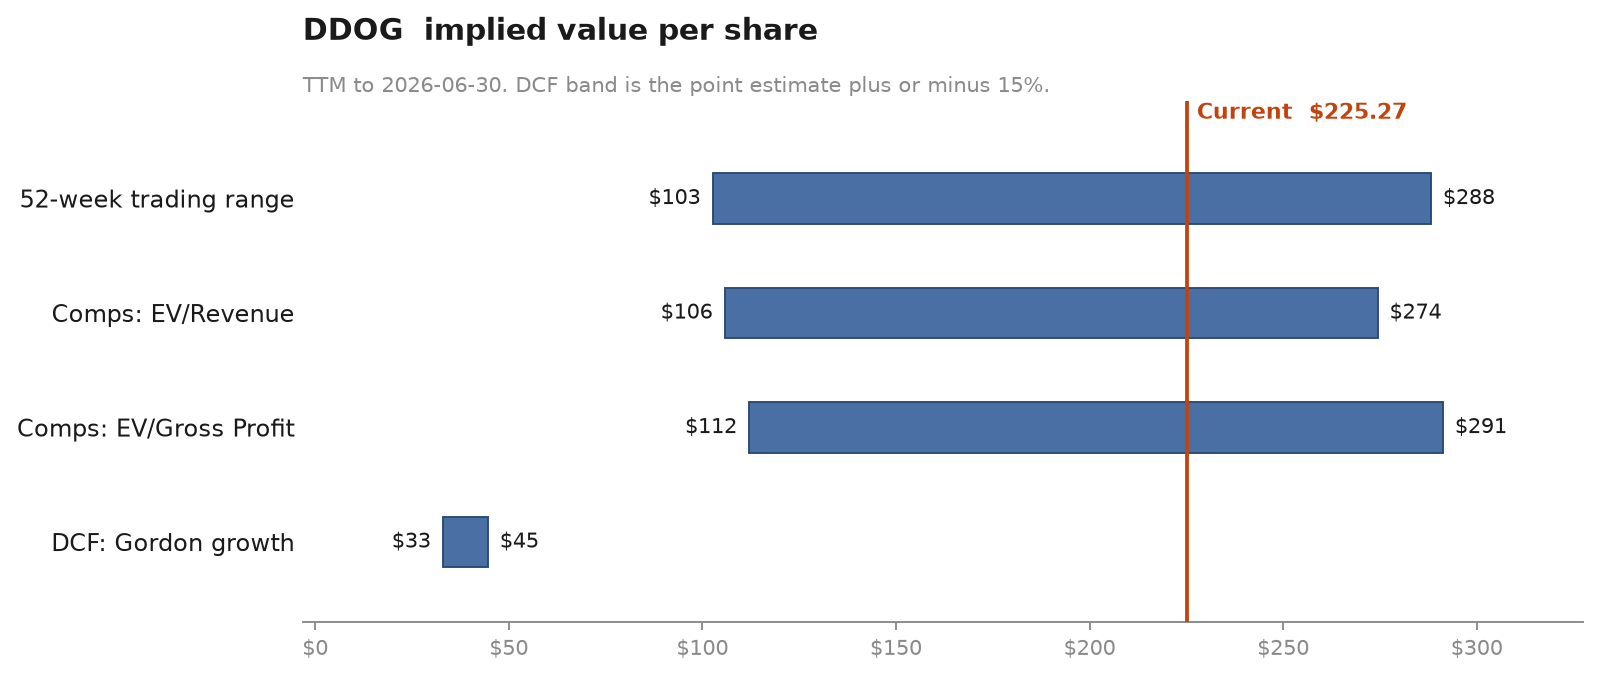

In [18]:
rows = []
lo, hi = market.prices("DDOG").fifty_two_week_range()
rows.append(FootballRow("52-week trading range", lo, hi))

for label in ("EV/Revenue", "EV/Gross Profit"):
    if label in comps.implied.index:
        r = comps.implied.loc[label]
        rows.append(FootballRow(f"Comps: {label}",
                                float(r["Implied price low"]),
                                float(r["Implied price high"])))

if dcf.per_share_gordon and dcf.per_share_gordon > 0:
    rows.append(FootballRow("DCF: Gordon growth",
                            dcf.per_share_gordon * 0.85,
                            dcf.per_share_gordon * 1.15))

path = football_field(rows, price, "DDOG", ROOT / "out" / "DDOG_notebook.png",
                      subtitle=f"TTM to {fin.as_of}. DCF band is the point estimate plus or minus 15%.")

from IPython.display import Image
Image(str(path))

## What to distrust

Every number above is traceable, which is not the same as being right. The
approximations that would draw a challenge in a review:

1. **Diluted WASO stands in for a treasury-stock share count.** It is a
   backward-looking average, so it understates the count for a company issuing
   steadily, and the strike-price detail needed to do better lives in dimensioned
   XBRL that `companyfacts` does not publish.
2. **Book value proxies the market value of debt**, in the bridge and in the WACC
   weights.
3. **The synthetic credit rating comes from interest coverage**, which says
   almost nothing about a net-cash issuer's default risk.
4. **The equity risk premium is an assumption**, and it is the largest
   unobservable in the output.
5. **A projected loss year books no tax benefit** and creates no carryforward the
   model later uses.
6. **The peer set is hand-picked.** Three peers here, six in the shipped config,
   and comparability is a judgment nobody automated.